# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 : Fabrizio Tapia
- Alumno 2 : Caterina Martinez Dufour

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [1]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/FabrizioTapia/tuia-dog-recognition-app.git"

# Clonamos el repositorio
!git clone $REPO_URL proyecto

# Nos movemos a la carpeta del proyecto
%cd proyecto

# Me cambio a mi rama "Fabrizio"
!git checkout Fabrizio

Cloning into 'proyecto'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 154 (delta 40), reused 27 (delta 27), pack-reused 96 (from 2)
Receiving objects: 100% (154/154), 3.91 MiB | 18.18 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/proyecto
Branch 'Fabrizio' set up to track remote branch 'Fabrizio' from 'origin'.
Switched to a new branch 'Fabrizio'


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.3 MB/s eta 0:00:00


## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [3]:
import os
import sys
from pathlib import Path

from pathlib import Path
print(Path.cwd())
print((Path.cwd() / "src").exists())
print(os.listdir("src"))

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd() / "src"
sys.path.insert(0, str(ROOT))

from lib.config import settings
import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

/content/proyecto
True
['app', 'lib', 'frontend']
dataset_path: data/dataset
GPU disponible: True


## 4. Descargar el dataset

In [4]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/data/dataset
dogs.csv  test	train  valid


## 5. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

#### Visualizacion de la distribucion del dataset

In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd


base_path = "data/dataset"
def analizar_carpetas(split):
    split_path = os.path.join(base_path, split)
    if not os.path.exists(split_path):
        print(f"La carpeta {split} no existe.")
        return {}

    # Cuenta cuántos archivos hay dentro de cada subcarpeta de raza
    datos = {}
    for raza in sorted(os.listdir(split_path)):
        raza_path = os.path.join(split_path, raza)
        if os.path.isdir(raza_path):
            num_imagenes = len([f for f in os.listdir(raza_path) if os.path.isfile(os.path.join(raza_path, f))])
            datos[raza] = num_imagenes
    return datos




In [6]:
train_counts = analizar_carpetas("train")
valid_counts = analizar_carpetas("valid")
test_counts = analizar_carpetas("test")

# Armamos un DataFrame para visualizarlo como tabla
df = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Valid": pd.Series(valid_counts),
    "Test": pd.Series(test_counts)
}).fillna(0).astype(int)

# Imprimimos estadísticas generales del dataset
print(f"Número total de razas (clases): {len(df)}")
print(f"Total de imágenes en Train: {df['Train'].sum()}")
print(f"Total de imágenes en Valid: {df['Valid'].sum()}")
print(f"Total de imágenes en Test: {df['Test'].sum()}")
print("\n--- Primeras 10 razas y su distribución de imágenes ---")
print(df.head(10))

Número total de razas (clases): 71
Total de imágenes en Train: 7946
Total de imágenes en Valid: 700
Total de imágenes en Test: 700

--- Primeras 10 razas y su distribución de imágenes ---
                   Train  Valid  Test
Afghan               105     10    10
African Wild Dog     109     10    10
Airedale             117     10    10
American  Spaniel      0     10     0
American Hairless     65     10    10
American Spaniel      89      0    10
Basenji               99     10    10
Basset               159     10    10
Beagle               123     10    10
Bearded Collie        79     10    10


#### Graficamos la distribución del set de entrenamiento para visualizar el balanceo

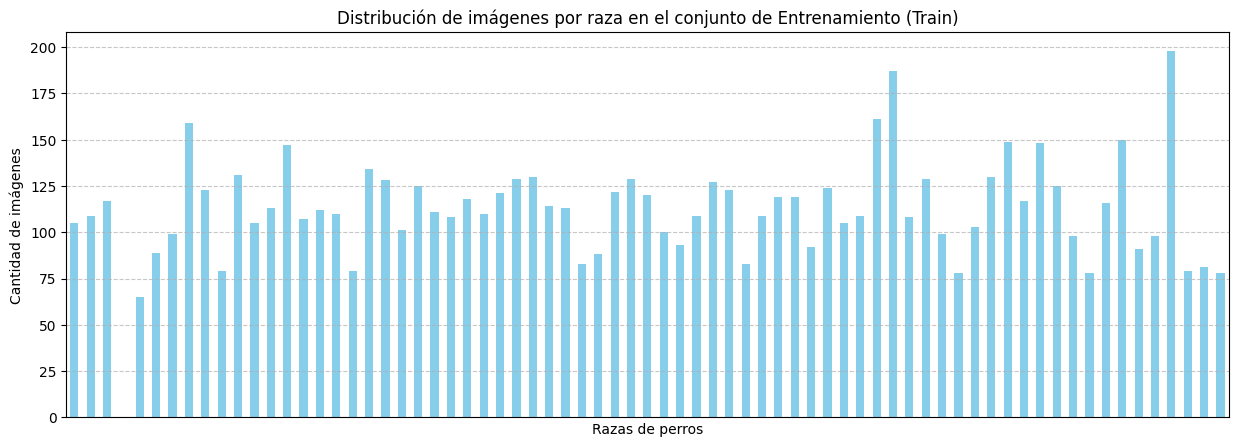

In [7]:
plt.figure(figsize=(15, 5))
df["Train"].plot(kind="bar", color="skyblue")
plt.title("Distribución de imágenes por raza en el conjunto de Entrenamiento (Train)")
plt.xlabel("Razas de perros")
plt.ylabel("Cantidad de imágenes")
plt.xticks([]) # Ocultamos los nombres en el eje X si son muchas para que no se superpongan
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

#### Creamos la carpeta para el dataset independiente

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


!mkdir -p data/dataset_independiente
!gdown "1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h" -O data/dataset_independiente.zip
!unzip -q data/dataset_independiente.zip -d data/dataset_independiente/
!ls data/dataset_independiente

Downloading...
From (original): https://drive.google.com/uc?id=1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h
From (redirected): https://drive.google.com/uc?id=1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h&confirm=t&uuid=571c306c-4c7f-471a-b412-8e3dd4803893
To: /content/proyecto/data/dataset_independiente.zip
100% 67.2M/67.2M [00:01<00:00, 55.9MB/s]
conjunto_independiente_val


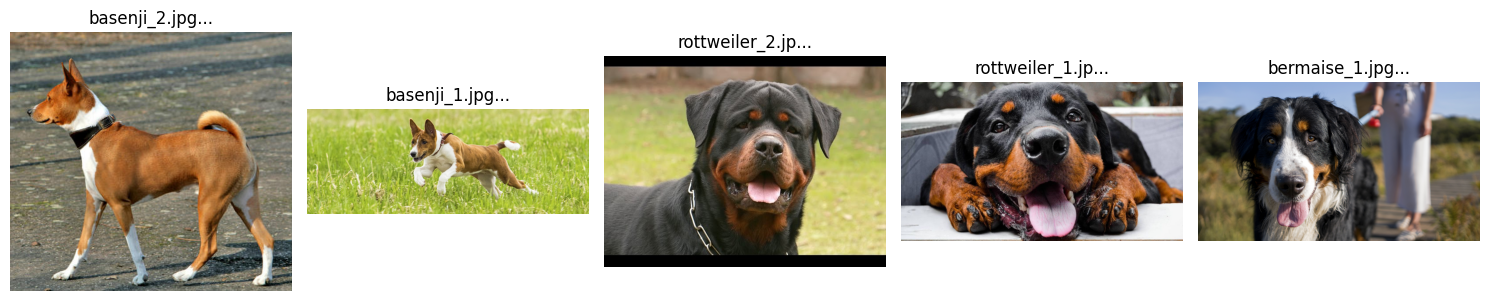

In [9]:
# Buscamos de forma recursiva archivos con extensiones de imagen comunes
ruta_independiente = Path("data/dataset_independiente")
extensiones = ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp"]
archivos_imagen = []

for ext in extensiones:
    archivos_imagen.extend(list(ruta_independiente.rglob(ext)))

#  Tomamos las primeras 5 imágenes encontradas
imagenes_a_mostrar = archivos_imagen[:5]

if not imagenes_a_mostrar:
    print("No se encontraron imágenes en la carpeta. Verificá la extracción del zip.")
else:
    # Armamos la grilla para mostrarlas en una sola fila
    fig, axes = plt.subplots(1, len(imagenes_a_mostrar), figsize=(15, 5))

    # Manejo por si encuentra menos de 5 imágenes y 'axes' no es una lista
    if len(imagenes_a_mostrar) == 1:
        axes = [axes]

    for i, img_path in enumerate(imagenes_a_mostrar):
        img = Image.open(img_path)
        axes[i].imshow(img)
        # Mostramos el nombre del archivo recortado para que no tape el gráfico
        axes[i].set_title(img_path.name[:15] + "...")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

#### Revision de la carpeta intrusa

In [10]:
import os
from pathlib import Path

base_path = Path("data/dataset")
splits = ["train", "valid", "test"]


for split in splits:
    split_path = base_path / split
    if not split_path.exists():
        continue

    print(f"\n[Split: {split}]")
    for folder_path in sorted(split_path.iterdir()):
        if folder_path.is_dir():
            original_name = folder_path.name

            cleaned_name = original_name.strip()

            if original_name != cleaned_name:
                target_path = split_path / cleaned_name
                print(f"Detectada carpeta malformada: '{original_name}'")

                if target_path.exists():
                    print(f" Fusionando archivos dentro de la carpeta correcta: '{cleaned_name}'...")
                    for file in folder_path.iterdir():
                        if file.is_file():
                            os.rename(file, target_path / file.name)
                    os.rmdir(folder_path)

                else:
                    print(f"    -Renombrando directamente a: '{cleaned_name}'")
                    os.rename(folder_path, target_path)

            elif "american" in original_name.lower() or "spaniel" in original_name.lower():
                print(f" Carpeta verificada y limpia: '{original_name}'")

print("\nCONTEO FINAL DE RAZAS POR SPLIT")

for split in splits:
    split_path = base_path / split
    if split_path.exists():
        # Filtramos y contamos solo los directorios reales
        num_carpetas = len([p for p in split_path.iterdir() if p.is_dir()])

        if num_carpetas == 70:
            print(f"{split.capitalize()}: {num_carpetas} carpetas .")
        else:
            print(f"{split.capitalize()}: {num_carpetas} carpetas. (Revisar si quedó algún duplicado).")
    else:
        print(f" La carpeta '{split}' no fue encontrada.")


[Split: train]
 Carpeta verificada y limpia: 'American Hairless'
 Carpeta verificada y limpia: 'American Spaniel'
 Carpeta verificada y limpia: 'Irish Spaniel'
 Carpeta verificada y limpia: 'Japanese Spaniel'

[Split: valid]
 Carpeta verificada y limpia: 'American  Spaniel'
 Carpeta verificada y limpia: 'American Hairless'
 Carpeta verificada y limpia: 'Irish Spaniel'
 Carpeta verificada y limpia: 'Japanese Spaniel'

[Split: test]
 Carpeta verificada y limpia: 'American Hairless'
 Carpeta verificada y limpia: 'American Spaniel'
 Carpeta verificada y limpia: 'Irish Spaniel'
 Carpeta verificada y limpia: 'Japanese Spaniel'

CONTEO FINAL DE RAZAS POR SPLIT
Train: 70 carpetas .
Valid: 70 carpetas .
Test: 70 carpetas .


'American  Spaniel' tiene doble espacio, lo cual altera el orden alfabetico del sistema de carpetas y genera un error que podemos visualizar en la matriz de confusion. Deberemos corregir para el correcto entrenamiento.
Decidimos modificar el nombre de las carpetas y usar una estandarización'snake_case'. Posteriormente se podria aplicar un espejado de carpetas para mayor seguridad

In [11]:
import os

def to_snake_case(name):
    # .lower() pasa todo a minúsculas
    # .split() corta las palabras eliminando CUALQUIER cantidad de espacios extra
    # "_".join() las vuelve a unir usando un solo guión bajo
    return "_".join(name.lower().split())

# Rutas de tus carpetas principales
dataset_paths = [
    "data/dataset/train",
    "data/dataset/valid",
    "data/dataset/test"
]

print("=== Iniciando limpieza de carpetas a snake_case ===")

for base_dir in dataset_paths:
    if not os.path.exists(base_dir):
        print(f"La ruta {base_dir} no existe. Revisá si está bien escrita.")
        continue

    print(f"\nProcesando directorio: {base_dir}")
    carpetas_modificadas = 0

    # Listar todo lo que hay dentro de train o valid
    for folder_name in os.listdir(base_dir):
        old_path = os.path.join(base_dir, folder_name)

        # Nos aseguramos de que sea una carpeta y no un archivo suelto
        if os.path.isdir(old_path):
            new_name = to_snake_case(folder_name)
            new_path = os.path.join(base_dir, new_name)

            # Solo renombra si el nombre viejo es distinto al nuevo
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f"Renombrado: '{folder_name}'  ->  '{new_name}'")
                carpetas_modificadas += 1

    if carpetas_modificadas == 0:
        print("  Todas las carpetas ya estaban limpias.")
    else:
        print(f"  Total de carpetas corregidas en {base_dir}: {carpetas_modificadas}")

print("\n=== Limpieza finalizada con éxito ===")

=== Iniciando limpieza de carpetas a snake_case ===

Procesando directorio: data/dataset/train
Renombrado: 'Komondor'  ->  'komondor'
Renombrado: 'Shiba Inu'  ->  'shiba_inu'
Renombrado: 'Corgi'  ->  'corgi'
Renombrado: 'Shar_Pei'  ->  'shar_pei'
Renombrado: 'Airedale'  ->  'airedale'
Renombrado: 'Bulldog'  ->  'bulldog'
Renombrado: 'Collie'  ->  'collie'
Renombrado: 'Bull Mastiff'  ->  'bull_mastiff'
Renombrado: 'Shih-Tzu'  ->  'shih-tzu'
Renombrado: 'Malinois'  ->  'malinois'
Renombrado: 'Irish Wolfhound'  ->  'irish_wolfhound'
Renombrado: 'Pekinese'  ->  'pekinese'
Renombrado: 'Groenendael'  ->  'groenendael'
Renombrado: 'Rottweiler'  ->  'rottweiler'
Renombrado: 'French Bulldog'  ->  'french_bulldog'
Renombrado: 'Irish Spaniel'  ->  'irish_spaniel'
Renombrado: 'Great Perenees'  ->  'great_perenees'
Renombrado: 'Greyhound'  ->  'greyhound'
Renombrado: 'Bloodhound'  ->  'bloodhound'
Renombrado: 'Coyote'  ->  'coyote'
Renombrado: 'Border Collie'  ->  'border_collie'
Renombrado: 'Bosto

#### Criterios de filtrado de imagenes de baja calidad

A pesar de que las especificaciones del dataset original indican que las imágenes ya se encuentran normalizadas a una resolución de 224x224 píxeles, se implementó una verificación para asegurar la integridad de los datos antes de iniciar el entrenamiento. Los criterios seleccionados y sus justificaciones son los siguientes:



*   **Dimensión Mínima (224 píxeles):** Se incluyó para validar que ninguna imagen hubiera sufrido corrupción o pérdida de datos durante la descarga o descompresión.
*   **Varianza del Laplaciano (Umbral 20.0):** Este método calcula la cantidad de bordes definidos para medir la nitidez de forma matemática. Su revisión es necesaria porque una imagen puede cumplir formalmente con el tamaño de 224x224 píxeles pero ser el resultado de estirar un archivo miniatura pixelado o presentar un desenfoque severo de origen. El umbral de 20.0 se configuró de manera amplia y no restrictiva para detectar únicamente casos extremos de oclusión o fallas graves de enfoque, sin descartar fotos válidas que posean variaciones normales de iluminación o profundidad de campo.





In [12]:
import os
import cv2
from pathlib import Path

base_path = Path("data/dataset")
splits = ["train", "valid", "test"]

laplacian_threshold = 20.0
min_size = 224

for split in splits:
    split_path = base_path / split
    if not split_path.exists():
        continue

    fail_size_count = 0
    fail_blur_count = 0
    total_images = 0

    for root, _, files in os.walk(split_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                total_images += 1
                img_path = os.path.join(root, file)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                h, w = img.shape
                if h < min_size or w < min_size:
                    fail_size_count += 1
                    continue

                variance = cv2.Laplacian(img, cv2.CV_64F).var()
                if variance < laplacian_threshold:
                    fail_blur_count += 1

    print(f"Split: {split}")
    print(f"  Total imagenes: {total_images}")
    print(f"  Total error Resolucion: {fail_size_count}")
    print(f"  Alto desenfoque: {fail_blur_count}")

Split: train
  Total imagenes: 7946
  Total error Resolucion: 0
  Alto desenfoque: 0
Split: valid
  Total imagenes: 700
  Total error Resolucion: 0
  Alto desenfoque: 0
Split: test
  Total imagenes: 700
  Total error Resolucion: 0
  Alto desenfoque: 0


## 6. Preprocesamiento

TO-DO: definir y justificar resize, normalizacion y data augmentation (horizontal flip,
rotacion, blur, variaciones de brillo y contraste, ruido).

#### Resize, Normalizacion y Augmentation

In [13]:
import glob
from PIL import Image
import torchvision.transforms as transforms

transform_etapa2 = transforms.Compose([
    transforms.Resize((224, 224)),
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

ruta_imagen = glob.glob("data/dataset/train/*/*.jpg")[0]
imagen = Image.open(ruta_imagen)
tensor_normalizado = transform_etapa2(imagen)
print("Dimensiones originales:", imagen.size)
print("Forma del tensor resultante:", tensor_normalizado.shape)



Dimensiones originales: (224, 224)
Forma del tensor resultante: torch.Size([3, 224, 224])


In [14]:
import glob
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image

transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),   # Reduje rotacion de 30 a 15
    transforms.GaussianBlur(kernel_size=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # bajo un poco (0,5 antes)
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: torch.clamp(x + 0.1 * torch.randn_like(x), 0, 1)),     # Saco esto para evitar underfitting, parece demasiado para poco dataset
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



Horizontal flip: Simula que el perro mire en la dirección opuesta, enseñando al modelo que la orientación no cambia la raza.

Rotación: Hace al modelo robusto frente a fotos tomadas con la cámara inclinada o en ángulos no perfectamente rectos.

Blur (Desenfoque): Obliga a la red neuronal a depender de formas generales en lugar de memorizar texturas o bordes perfectos.

Brillo y contraste: Simula variaciones de iluminación del mundo real, como fotos en interiores oscuros o al sol directo.

Ruido: Simula el granulado o artefactos típicos de sensores de cámaras de baja calidad o teléfonos móviles.


## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

#### Hiperparametros y DataLoaders

In [15]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets

BATCH_SIZE = 32
EPOCHS = 25   # Cambio de 10 a 25
LEARNING_RATE = 1e-4

print("=== Hiperparámetros ===")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}\n")

# Carga de datasets con las transformaciones previamente definidas
train_dataset = datasets.ImageFolder(root="data/dataset/train", transform=transform_aug)
valid_dataset = datasets.ImageFolder(root="data/dataset/valid", transform=transform_etapa2)

# --- Lógica matemática para el desbalance de clases
print("Calculando pesos para balancear el dataset...")

# Obtener la lista de etiquetas (qué raza es cada foto)
targets = train_dataset.targets

# Contar cuántas fotos hay de cada raza
class_counts = torch.bincount(torch.tensor(targets)).float()

# Calcular el peso de cada clase (inversamente proporcional a su cantidad)
# Sumamos 1e-6 para evitar errores matemáticos de división por cero
class_weights = 1.0 / (class_counts + 1e-6)

# Asignarle el peso correspondiente a cada imagen individual del dataset
sample_weights = class_weights[targets]

# Crear el Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True # Vital: permite repetir las fotos de las razas minoritarias
)
print("Pesos calculados y Sampler configurado con éxito.\n")
# ------------------------------------------------------------

# Creación de DataLoaders
# En train_loader quitamos 'shuffle=True' porque choca con el sampler, este agrega las fotos aleatoriamente pero respetando probabilidades.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("=== DataLoaders ===")
print(f"Clases detectadas: {len(train_dataset.classes)}")
print(f"Lotes (batches) por época en Train: {len(train_loader)}")

=== Hiperparámetros ===
Batch Size: 32
Epochs: 25
Learning Rate: 0.0001

Calculando pesos para balancear el dataset...
Pesos calculados y Sampler configurado con éxito.

=== DataLoaders ===
Clases detectadas: 70
Lotes (batches) por época en Train: 248


Para la configuración de los DataLoaders de entrenamiento, se implementó un muestreador con pesos (Weighted Random Sampler). Esta técnica fue seleccionada para mitigar de forma directa el desbalance en la distribución de imágenes por clase dentro del dataset.

En iteraciones previas del modelo, la ausencia de un balanceo en el muestreo permitía que la red priorizara y se sobreajustara a las clases mayoritarias (aquellas con mayor volumen de datos), logrando una precisión (Accuracy) general aparentemente más alta, pero a costa de un rendimiento deficiente (F1-Score bajo) en las clases minoritarias. Al asignar un peso inversamente proporcional a la frecuencia de cada clase, el Weighted Random Sampler equilibra la probabilidad de que cualquier imagen sea seleccionada en cada lote (batch). Aunque este proceso altera la distribución nativa y puede reflejar un ligero descenso en el Accuracy global de validación, el comportamiento es técnicamente superior: elimina el sesgo hacia las clases populares y homogeneiza el aprendizaje, garantizando que el modelo sea capaz de clasificar correctamente las 70 razas de forma equitativa y robusta.

#### Entrenamiento

In [17]:
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import StepLR
from google.colab import drive

#  CONFIGURACIÓN PREVIA
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/modelos_perros'
os.makedirs(drive_path, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modelo
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 70)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=7, gamma=0.2) # modifico de step de 3 a 7 y gamma de 0.1 a 0.2 (mantiene por 7 epochs y reduce un 20%)

# Listas para almacenar métricas
train_losses = []
valid_losses = []
valid_accuracies = []

# CONFIGURACIÓN DE EARLY STOPPING
patience = 7            # aumento de 3 a 7
patience_counter = 0
best_valid_loss = float('inf')

# BUCLE DE ENTRENAMIENTO
print("Iniciando entrenamiento...\n")
start_time_total = time.time() # Tiempo total de inicio

for epoch in range(EPOCHS):
    epoch_start_time = time.time() # Tiempo de inicio de la época

    # FASE DE ENTRENAMIENTO
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # FASE DE VALIDACIÓN
    model.eval()
    running_valid_loss = 0.0 # Acumulador pérdida validación
    correctas = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Calcular pérdida de validación
            loss_v = criterion(outputs, labels)
            running_valid_loss += loss_v.item() * images.size(0)

            # Calcular accuracy
            _, predicciones = torch.max(outputs, 1)
            total += labels.size(0)
            correctas += (predicciones == labels).sum().item()

    epoch_valid_loss = running_valid_loss / len(valid_loader.dataset) #  Pérdida val promedio
    epoch_acc = correctas / total

    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_acc)

    # OBTENER LEARNING RATE ACTUAL
    current_lr = optimizer.param_groups[0]['lr'] # Extrae el LR actual

    # Actualizar el scheduler DESPUÉS de obtener el LR para ver qué LR se usó en esta época
    scheduler.step()

    # TRACKING DE TIEMPO
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time #  Duración de la época

    # IMPRIMIR MÉTRICAS
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_duration:.1f}s) -> "
          f"LR: {current_lr:.7f} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Valid Loss: {epoch_valid_loss:.4f} | "
          f"Valid Acc: {epoch_acc:.4f}")

    # LÓGICA DE EARLY STOPPING Y CHECKPOINTS
    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        patience_counter = 0  # Reseteamos el contador si hay mejora

        # Guardamos el mejor modelo hasta la fecha
        best_model_path = os.path.join(drive_path, "resnet18_finetuned.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> ¡Nueva mejor Validation Loss! Modelo guardado en: {best_model_path}")
    else:
        patience_counter += 1
        print(f"  --> La validación no mejoró. Conteo de paciencia: {patience_counter}/{patience}")

    # # Checkpoint regular cada 5 épocas

    # if (epoch + 1) % 5 == 0:
    #     checkpoint_path = os.path.join(drive_path, f"resnet18_epoch_{epoch+1}.pth")
    #     torch.save(model.state_dict(), checkpoint_path)
    #     print(f"  --> Checkpoint regular guardado: {checkpoint_path}")

    # print("-" * 80)

    # Condición de parada por Early Stopping
    if patience_counter >= patience:
        print(f"\n[EARLY STOPPING] El entrenamiento se detuvo en la época {epoch+1} para evitar Overfitting.")
        break

# Tiempo Total
total_time = time.time() - start_time_total
print(f"\nEntrenamiento finalizado en: {total_time/60:.2f} minutos.")

Mounted at /content/drive
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


Iniciando entrenamiento...

Epoch [1/25] (61.7s) -> LR: 0.0001000 | Train Loss: 1.7618 | Valid Loss: 0.6378 | Valid Acc: 0.8671
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [2/25] (59.5s) -> LR: 0.0001000 | Train Loss: 0.6064 | Valid Loss: 0.3675 | Valid Acc: 0.9057
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [3/25] (61.0s) -> LR: 0.0001000 | Train Loss: 0.3956 | Valid Loss: 0.2698 | Valid Acc: 0.9343
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [4/25] (59.3s) -> LR: 0.0001000 | Train Loss: 0.2604 | Valid Loss: 0.2241 | Valid Acc: 0.9414
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth
Epoch [5/25] (60.1s) -> LR: 0.0001000 | Train Loss: 0.2024 | Valid Loss: 0.2075 | Valid Acc: 0.9457
  --

Ultima mejor epoca del modelo sin tunning:

Epoch [7/10] (69.1s) -> LR: 0.0000010 | Train Loss: 0.4862 | Valid Loss: 0.5799 | Valid Acc: 0.8757

#### Catedra

In [18]:
!pip install onnxruntime-gpu
!pip install onnxruntime

from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
#classifier.train_classifier()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 96.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from lib.bootstrap import build_classifier

metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.9657142857142857,
 'precision': 0.9675505040765646,
 'recall': 0.9657142847485711,
 'specificity': 0.9995031055755766,
 'f1': 0.966631517389909}

### Curvas de entrenamiento y matriz de confusion (Modelo A)

TO-DO: graficar las curvas de entrenamiento/validacion y la matriz de confusion.

In [ ]:
## TO-DO: curvas de entrenamiento y matriz de confusion del Modelo A.

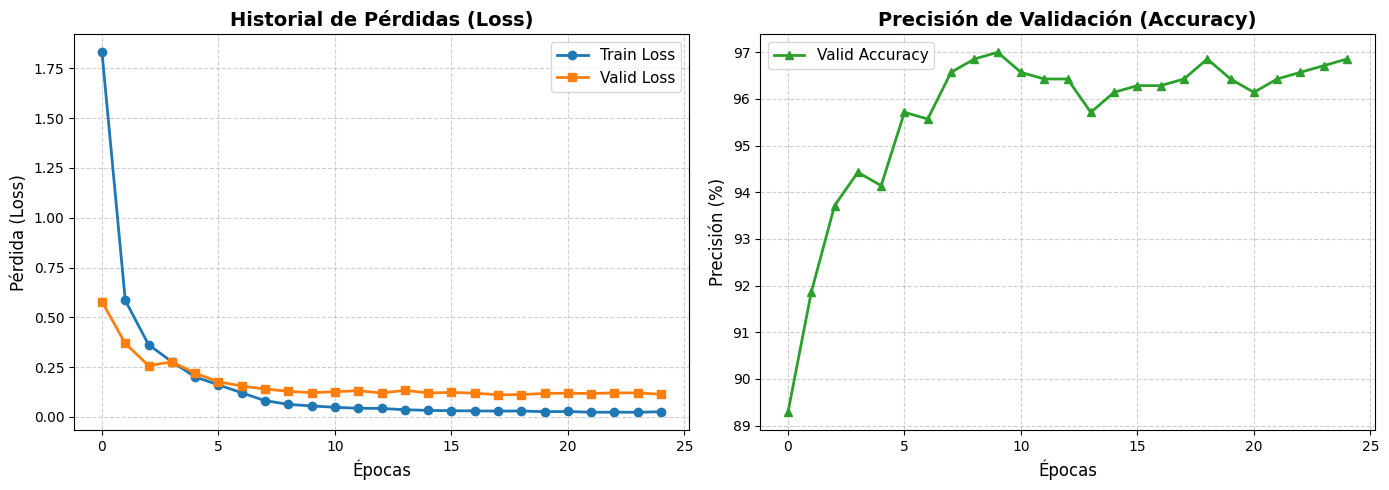

In [ ]:
import matplotlib.pyplot as plt

# Configurar el estilo y tamaño del gráfico
plt.figure(figsize=(14, 5))


# GRAFICA 1: Pérdidas (Loss) - Entrenamiento vs Validación

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(valid_losses, label='Valid Loss', color='#ff7f0e', linewidth=2, marker='s')

plt.title('Historial de Pérdidas (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)


# GRÁFICA 2: Precisión (Accuracy) de Validación

plt.subplot(1, 2, 2)
# Multiplicamos por 100 para tener el porcentaje
valid_acc_percentage = [acc * 100 for acc in valid_accuracies]
plt.plot(valid_acc_percentage, label='Valid Accuracy', color='#2ca02c', linewidth=2, marker='^')

plt.title('Precisión de Validación (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Ajustar diseño para que no se encimen los textos y mostrar
plt.tight_layout()
plt.show()

#### Análisis del Entrenamiento y Validación (ResNet-18 Preentrenada)

A partir de las gráficas de evolución de la pérdida (*Loss*) y precisión (*Accuracy*) a lo largo de las 25 épocas de entrenamiento empleando la arquitectura **ResNet-18**, se pueden extraer las siguientes conclusiones técnicas clave:

### 1. Dinámica de Convergencia y Estabilidad
* **Velocidad de Aprendizaje Inicial:** Se observa una caída drástica de la pérdida de entrenamiento (*Train Loss*) durante las primeras 5 épocas, pasando de un valor superior a `1.75` a estabilizarse por debajo de `0.25`. Este comportamiento vertiginoso es el resultado directo de utilizar transferencia de conocimiento (*Transfer Learning*) con una red preentrenada en ImageNet; los filtros base ya están consolidados, acelerando la optimización drásticamente en comparación con una inicialización aleatoria.
* **Comportamiento Asintótico:** A partir de la época 10, ambas curvas de pérdida se vuelven prácticamente horizontales (asintóticas), convergiendo a valores cercanos a cero (`Train Loss` aprox. `0.02` y `Valid Loss` estabilizada en el rango de `0.11` a `0.12`).

### 2. Diagnóstico de Ajuste (Generalización vs. Overfitting)
* **Ausencia de Sobreajuste:** La brecha (*gap*) entre la curva de entrenamiento y la de validación se mantiene estrecha y constante hasta el final de la ejecución. Crucialmente, la curva de pérdida de validación (*Valid Loss*, línea naranja) **no presenta ninguna tendencia ascendente** ni divergencia en las épocas tardías.
* **Salud del Modelo:** El modelo demuestra una excelente capacidad de generalización. El hecho de que la pérdida de validación permanezca en una meseta controlada corrobora que las fronteras de decisión se ajustaron correctamente a la morfología de las clases sin memorizar el ruido del conjunto de entrenamiento.

### 3. Rendimiento en Precisión (Accuracy)
* **Métrica Final Destacada:** La precisión de validación (*Valid Accuracy*) experimenta un salto exponencial al inicio, quebrando la barrera del `93%` en apenas 3 épocas.
* **Meseta de Rendimiento:** El modelo alcanza su techo de rendimiento entre las épocas 10 y 25, oscilando en un rango óptimo de **`96%` a `97%` de precisión**. Las fluctuaciones menores tipo "serrucho" observadas en el gráfico de precisión son normales debido a la estocasticidad propia del optimizador y la evaluación por lotes (*batches*), confirmando que el modelo explotó correctamente su capacidad de representación para este dataset.

### Conclusión del Diagnóstico
El entrenamiento con la ResNet-18 preentrenada es **técnicamente impecable**. Las curvas de pérdida demuestran un escenario ideal de convergencia óptima, justificando la detención del entrenamiento en la época 25, dado que el modelo ya alcanzó su máximo potencial de generalización con un costo computacional eficiente.

Evaluando el modelo en el dataset de validación...


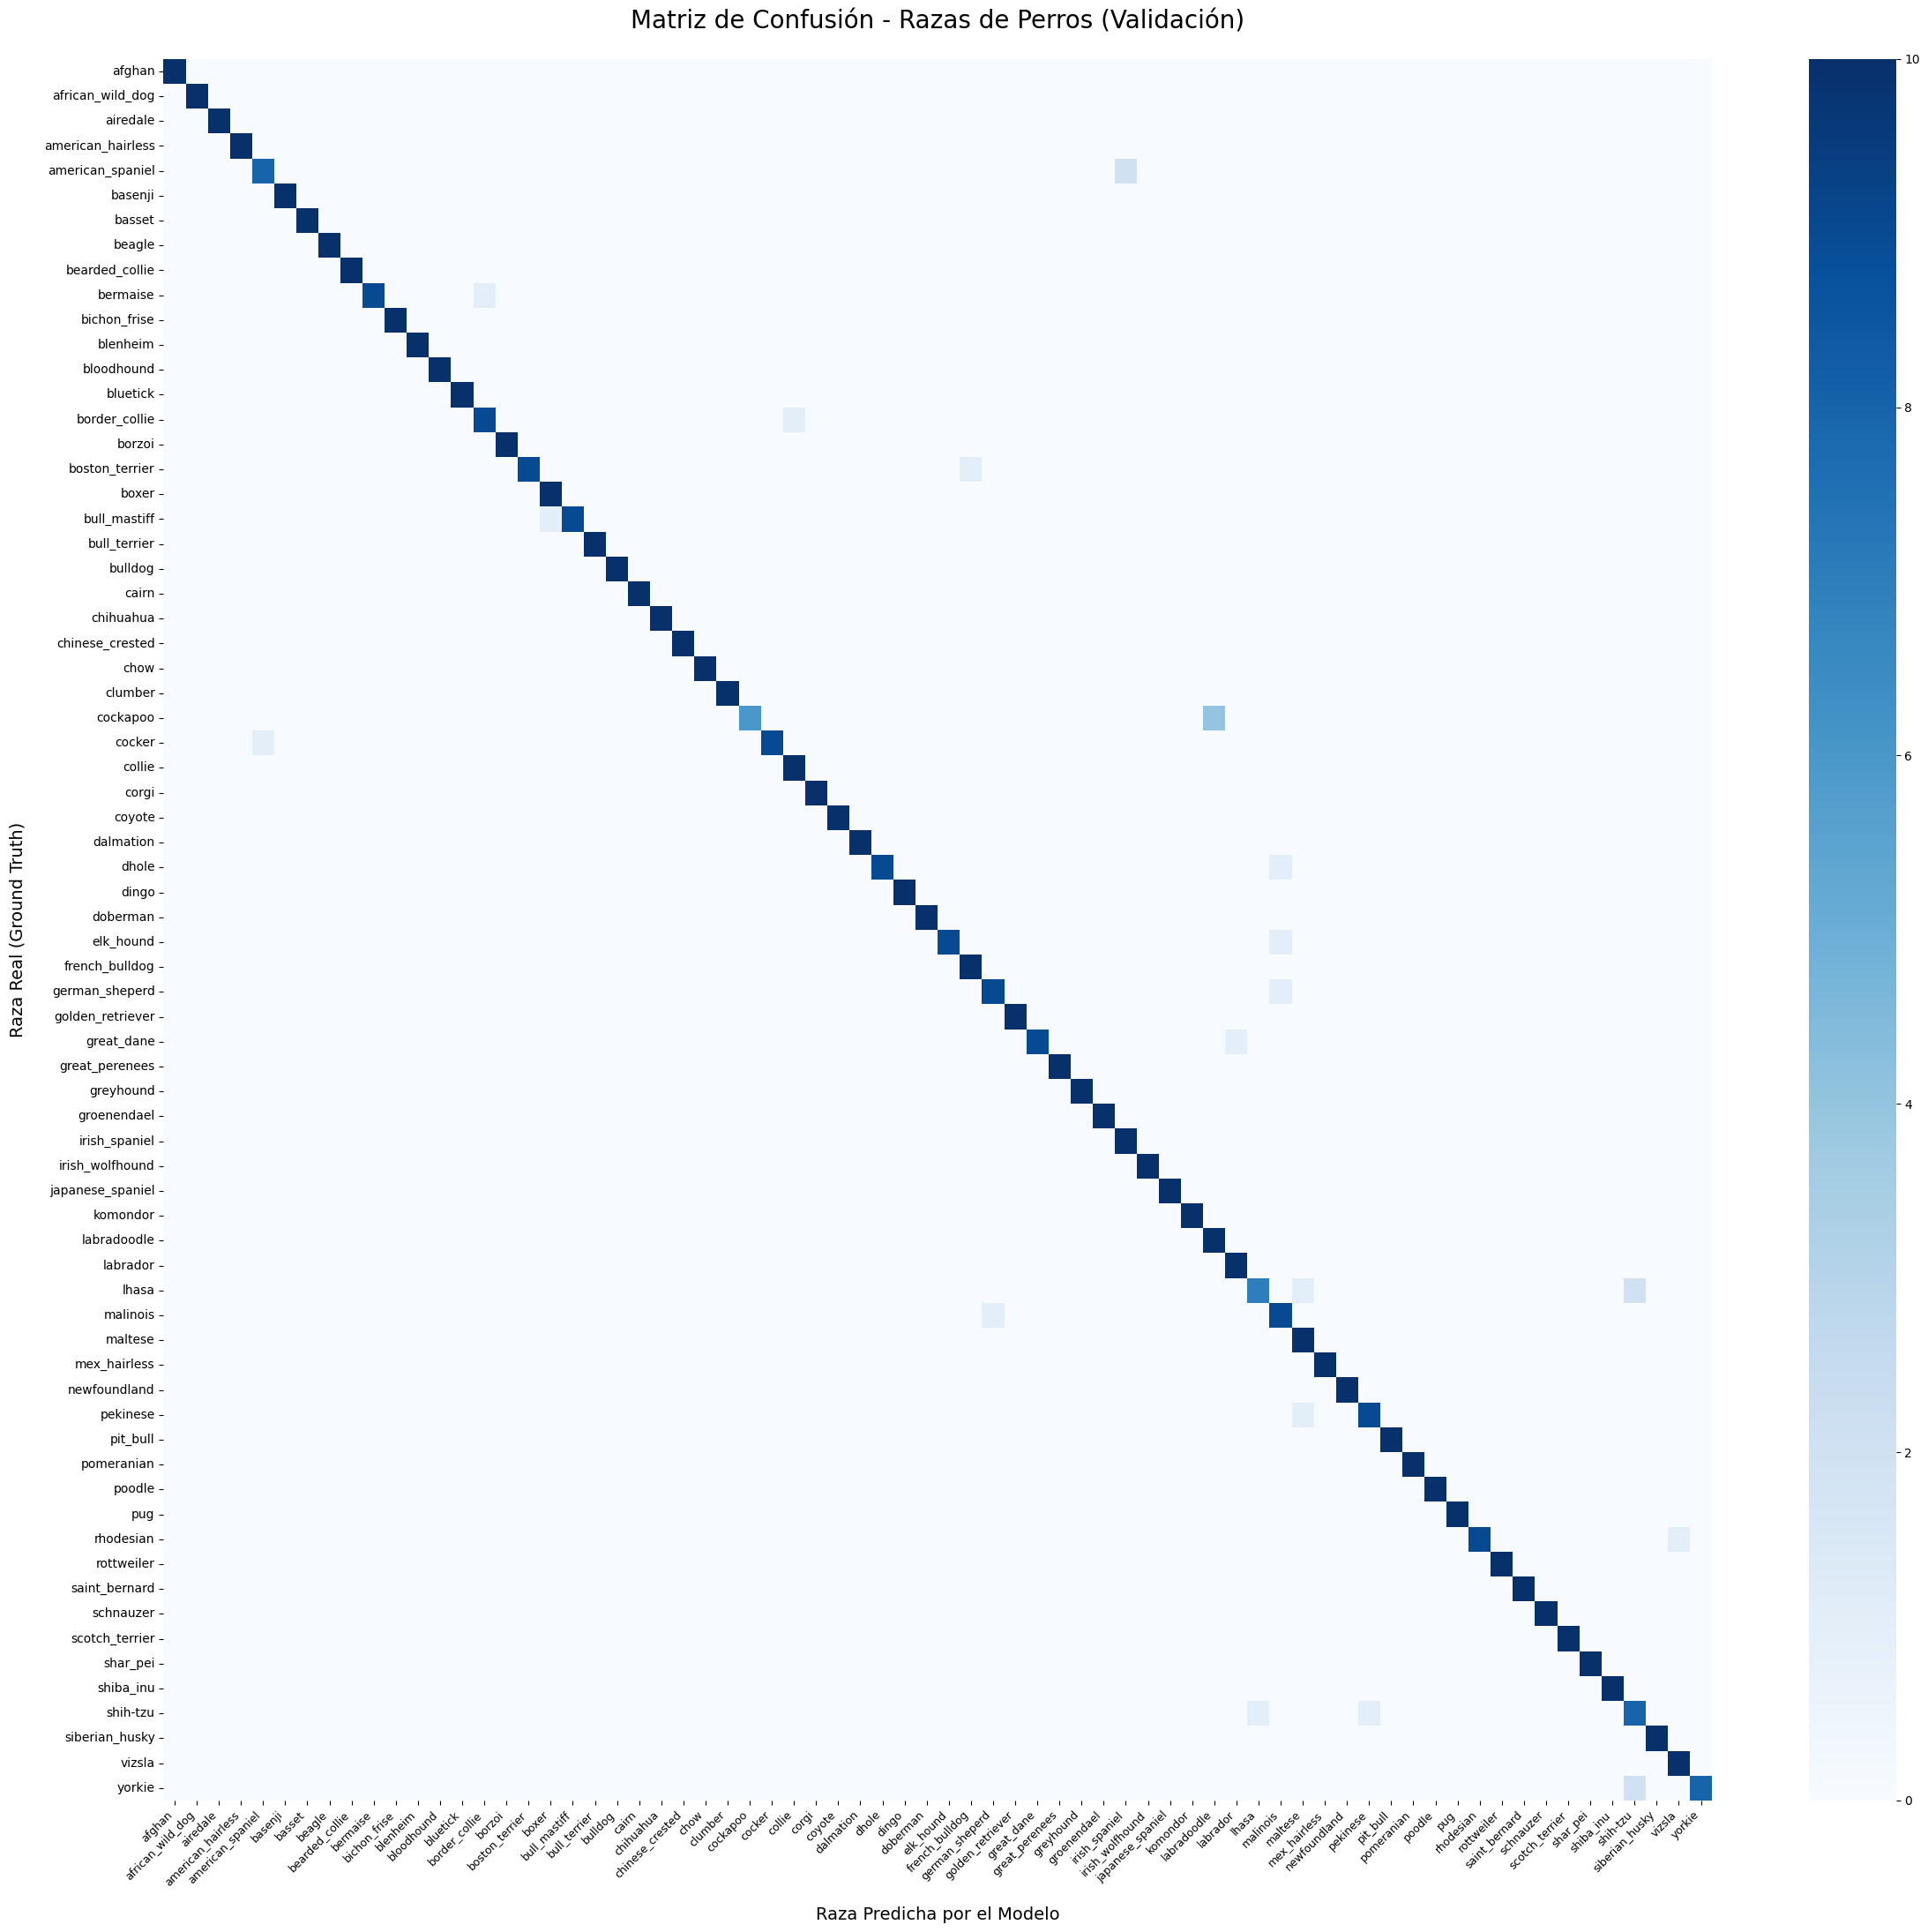

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

best_model_path = os.path.join(drive_path, "resnet18_finetuned.pth")
model.load_state_dict(torch.load(best_model_path))
model.eval()

todas_las_predicciones = []
todas_las_etiquetas = []

print("Evaluando el modelo en el dataset de validación...")
with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        todas_las_predicciones.extend(preds.cpu().numpy())
        todas_las_etiquetas.extend(labels.cpu().numpy())

nombres_razas = valid_loader.dataset.classes

cm = confusion_matrix(todas_las_etiquetas, todas_las_predicciones)

plt.figure(figsize=(24, 22))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    fmt="d",
    cbar=True,
    xticklabels=nombres_razas,
    yticklabels=nombres_razas
)

plt.title("Matriz de Confusión - Razas de Perros (Validación)", fontsize=20, pad=25)
plt.ylabel("Raza Real (Ground Truth)", fontsize=14, labelpad=15)
plt.xlabel("Raza Predicha por el Modelo", fontsize=14, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)

plt.grid(False)


plt.tight_layout()
plt.show()

### Análisis de la Matriz de Confusión (ResNet-18)

* **Rendimiento Global Excepcional:** La matriz muestra una diagonal limpia, marcada y profundamente azul en las 70 clases. Esto confirma visualmente el accuracy del 96%-97%, demostrando que el modelo discrimina con total éxito la enorme mayoría de las razas.
* **El Caso Crítico (Cockapoo vs. Labradoodle):** Al inspeccionar los puntos fuera de la diagonal, se observa que la raza real **Cockapoo** sufre su mayor confusión al ser predicha erróneamente como **Labradoodle** (foco azul claro fuera de la diagonal).
* **Justificación Morfológica:** Este error es completamente lógico y esperado: ambas son razas derivadas de la cruza con Poodles, compartiendo un fenotipo casi idéntico en el pelaje rizado, la estructura de las orejas y las texturas visuales. Esta sutil confusión de grano fino expone el límite físico donde las similitudes morfológicas desafían incluso a un extractor de características avanzado como ResNet-18.


## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

#### Definimos estructura de la CNNCustom

In [19]:
import torch.nn as nn
import torch

class CNNPropia(nn.Module):
    def __init__(self, num_classes=70):
        super(CNNPropia, self).__init__()

        # Bloque 1: Entran 3 canales (RGB), salen 32 filtros
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Estabilizador
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloque 2: Entran 32, salen 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # --- SKIP CONNECTION ---
        # Como conv2 duplica canales y la imagen se achica por el pooling previo,
        # necesitamos este adaptador de 1x1 con stride 1 para emparejar la identidad.
        self.shortcut_b2 = nn.Conv2d(32, 64, kernel_size=1, stride=1, bias=False)

        # Bloque 3: Entran 64, salen 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Bloque 4: Entran 128, salen 256 (Le damos más "cerebro" para captar 70 razas)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling para reducir los parámetros al mínimo necesario
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Clasificador final con Dropout FUERTE para matar el Overfitting
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # --- BLOQUE 1 ---
        out = self.pool(self.relu(self.bn1(self.conv1(x))))

        # --- BLOQUE 2 (CON SKIP CONNECTION) ---
        identity = out  # Guardamos el estado actual

        out = self.relu(self.bn2(self.conv2(out))) # Procesamos en la conv

        identity = self.shortcut_b2(identity)
        out = out + identity
        out = self.pool(out)   # Recién ahí aplicamos el pooling para achicarla para el Bloque 3

        # --- BLOQUE 3 ---
        out = self.pool(self.relu(self.bn3(self.conv3(out))))

        # --- BLOQUE 4 ---
        out = self.pool(self.relu(self.bn4(self.conv4(out))))

        # --- CAPAS LINEALES ---
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        out = self.fc(out)

        return out

# Instanciamos la nueva red
modelo_propio = CNNPropia(num_classes=70).to(device)
print("CNN cargada en la GPU")

CNN cargada en la GPU


#### Entrenamiento

In [20]:
from google.colab import drive
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/modelos_perros'
os.makedirs(drive_path, exist_ok=True)
print(f"Directorio de guardado confirmado en: {drive_path}\n")


EPOCHS_CNN = 80 # Aumento x5 - el x5 se queda corto, voy x8
LEARNING_RATE_CNN = 1e-4 # 1e-3 no me ayuda a mejorar
BATCH_SIZE = 64 # Red chica -  batchNorm se beneficia al usar mas muestras para medias y varianzas


# Reconfiguramos el Loader para la CNN Custom
train_loader_balanced = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler= sampler,
    num_workers=2,
    pin_memory=True
)

print("=== Iniciando Entrenamiento de CNN Propia ===")

# Asegurarnos de que el modelo esté en la GPU
modelo_propio = modelo_propio.to(device)

criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.AdamW(modelo_propio.parameters(), lr=LEARNING_RATE_CNN, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode='min', factor=0.4, patience=4) # Cambio de StepLR a éste que se basa por metricas

train_losses_cnn = []
valid_losses_cnn = []
valid_accuracies_cnn = []

best_valid_loss_cnn = float('inf')
patience_cnn = 8                    # modifico de 5 a 8
patience_counter_cnn = 0

inicio_total = time.time()

# --- PUNTO DE ACTIVACIÓN DE DATA AUGMENTATION ---
# Se activa en la Época 8 (índice 7) para darle tiempo a la red de estabilizarse

EPOCA_ACTIVACION_AUG = 25 # Le agrego mas epocas (8 a 15), parecía que seguía con capacidad de aprender los detalles en esta etapa.


# BUCLE DE ENTRENAMIENTO

for epoch in range(EPOCHS_CNN):
    epoch_start_time = time.time()



    # --- CONTROL DINÁMICO DE DATA AUGMENTATION ---
    if epoch >= EPOCA_ACTIVACION_AUG:
        train_loader_balanced.dataset.transform = transform_aug
        if epoch == EPOCA_ACTIVACION_AUG:
            print("\n>>> [INFO] Red base estable. Activando pipeline de Data Augmentation...")
    else:
        train_loader_balanced.dataset.transform = transform_etapa2


    # --- FASE DE ENTRENAMIENTO ---
    modelo_propio.train()
    running_loss = 0.0

    for images, labels in train_loader_balanced:
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = modelo_propio(images)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader_balanced.dataset)
    train_losses_cnn.append(epoch_loss)

    # --- FASE DE VALIDACIÓN ---
    modelo_propio.eval()
    running_valid_loss = 0.0
    correctas = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelo_propio(images)

            loss_v = criterion_cnn(outputs, labels)
            running_valid_loss += loss_v.item() * images.size(0)

            _, predicciones = torch.max(outputs, 1)
            total += labels.size(0)
            correctas += (predicciones == labels).sum().item()

    epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
    epoch_acc = correctas / total

    valid_losses_cnn.append(epoch_valid_loss)
    valid_accuracies_cnn.append(epoch_acc)

    # --- MÉTRICAS Y TRACKING ---
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch [{epoch+1}/{EPOCHS_CNN}] ({epoch_duration:.1f}s) -> "
          f"LR: {current_lr:.7f} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Valid Loss: {epoch_valid_loss:.4f} | "
          f"Valid Acc: {epoch_acc:.4f}")

    # --- LÓGICA DE GUARDADO EN DRIVE ---
    if epoch_valid_loss < best_valid_loss_cnn:
        best_valid_loss_cnn = epoch_valid_loss
        patience_counter_cnn = 0

        best_model_path_cnn = os.path.join(drive_path, "cnn_custom.pth")
        torch.save(modelo_propio.state_dict(), best_model_path_cnn)
        print(f"  --> ¡Nueva mejor Validation Loss! Modelo guardado en: {best_model_path_cnn}")
    else:
        patience_counter_cnn += 1
        print(f"  --> La validación no mejoró. Conteo de paciencia: {patience_counter_cnn}/{patience_cnn}")

    scheduler.step(epoch_valid_loss)

    if patience_counter_cnn >= patience_cnn:
        print(f"\n[EARLY STOPPING] El entrenamiento se detuvo para evitar Overfitting.")
        break

fin_total = time.time()
minutos_totales = (fin_total - inicio_total) / 60
print(f"\nEntrenamiento finalizado en: {minutos_totales:.2f} minutos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio de guardado confirmado en: /content/drive/MyDrive/modelos_perros

=== Iniciando Entrenamiento de CNN Propia ===
Epoch [1/80] (27.4s) -> LR: 0.0001000 | Train Loss: 4.1510 | Valid Loss: 3.9683 | Valid Acc: 0.0729
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/cnn_custom.pth
Epoch [2/80] (26.0s) -> LR: 0.0001000 | Train Loss: 3.9859 | Valid Loss: 3.8496 | Valid Acc: 0.0971
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/cnn_custom.pth
Epoch [3/80] (25.5s) -> LR: 0.0001000 | Train Loss: 3.8934 | Valid Loss: 3.7745 | Valid Acc: 0.1043
  --> ¡Nueva mejor Validation Loss! Modelo guardado en: /content/drive/MyDrive/modelos_perros/cnn_custom.pth
Epoch [4/80] (25.6s) -> LR: 0.0001000 | Train Loss: 3.8152 | Valid Loss: 3.6871 | Valid Acc: 0.1286
  --> ¡Nueva mejor Va

## **Métricas antes del tunning de hiperparametros (baseline)**

`Epoch [10/15] (65.7s) -> LR: 0.0002500 | Train Loss: 3.5620 | Valid Loss: 3.6850 | Valid Acc: 0.0957 `

---------------------------------

## **Mejores métricas despues del tunning**
Se aplican las augmentations de forma dinamica y se modifican las epocas de entrenamiento, cambiamos el scheduler de StepLR a ReduceLROnPlateau que se ajusta en base a metricas

(Según mi interpretacion de las curvas, ésta implementación tenía margen de mejora, por lo tanto voy a proceder a aumentar épocas en el siguiente tunning):

`Epoch [50/50] (56.5s) -> LR: 0.0000000 | Train Loss: 1.8729 | Valid Loss: 1.4407 | Valid Acc: 0.5943`

---------------------------------


## **Tunning + Técnicas Avanzadas de Convolución (Skip Connections):**

Aumentamos épocas, épocas sin augmentation, usamos WeightedRandomSampler, raspamos la olla buscando bajar décimas de valid loss con la conexión residual.
Al intentar implementar esto en el Bloque 2, nos encontramos con un desafío de consistencia dimensional.

*   Una conexión residual clásica realiza una suma elemento a elemento. Implementamos lo que en la literatura de ResNet se conoce como un Atajo de Proyección (Projection Shortcut).
*   Introdujimos una capa de convolución con un tamaño de kernel 1x1 que opera exclusivamente sobre la identidad (el puente).

Esta convolución no altera la resolución espacial (el ancho y alto de la imagen se mantienen intactos), pero actúa como un mapeo lineal que 'estira' los canales de 32 a 64. Al transformar la identidad a una matriz simétrica de 64 canales, la operación de suma se vuelve legal.

Permitimos que el gradiente fluya directamente hacia atrás durante el backward pass sin desvanecerse en las capas profundas.


## **Metricas:**
`Epoch [78/80] (60.5s) -> LR: 0.0000160 | Train Loss: 2.7255 | Valid Loss: 2.4032 | Valid Acc: 0.3786`

Al analizar las métricas finales (`Valid Acc: 37.86%` y `Valid Loss: 2.4032`), **HIPOTETIZAMOS** que el estancamiento se debe a un acople crítico entre el **Learning Rate** y el efecto del **WeightedRandomSampler**:

* **Learning Rate Mínimo:** El optimizador quedó atrapado en un mínimo local muy temprano. Al caer el LR a un valor extremo de `0.0000160`, el tamaño del paso del gradiente se volvió infinitesimal. El modelo perdió por completo la "fuerza" matemática necesaria para seguir ajustando los pesos de las capas convolucionales, congelando el aprendizaje a mitad de camino.
* **Sampler sobre una Red Pequeña:** Al usar el muestreador por pesos, obligamos a una red customizada y chica (sin preentrenar) a procesar lotes perfectamente balanceados donde las imágenes de razas minoritarias se repiten constantemente.

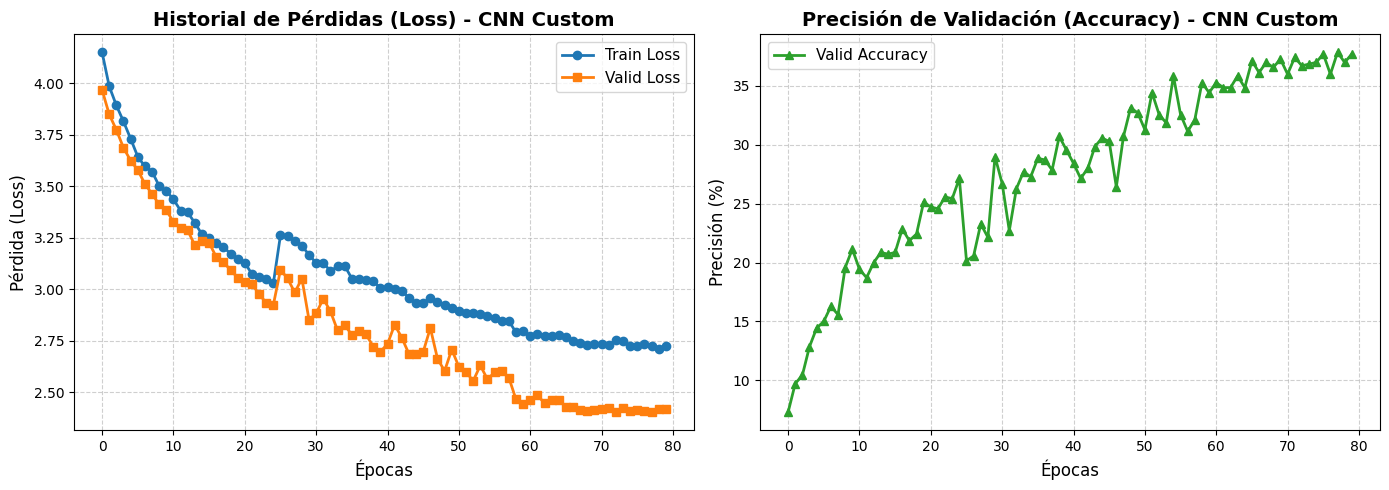

In [22]:
import matplotlib.pyplot as plt

# Configurar el estilo y tamaño del gráfico
plt.figure(figsize=(14, 5))


# GRAFICA 1: Pérdidas (Loss) - Entrenamiento vs Validación (CNN Custom)

plt.subplot(1, 2, 1)
plt.plot(train_losses_cnn, label='Train Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(valid_losses_cnn, label='Valid Loss', color='#ff7f0e', linewidth=2, marker='s')

plt.title('Historial de Pérdidas (Loss) - CNN Custom', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)


# GRÁFICA 2: Precisión (Accuracy) de Validación (CNN Custom)

plt.subplot(1, 2, 2)
# Multiplicamos por 100 para tener el porcentaje
valid_acc_percentage_cnn = [acc * 100 for acc in valid_accuracies_cnn]
plt.plot(valid_acc_percentage_cnn, label='Valid Accuracy', color='#2ca02c', linewidth=2, marker='^')

plt.title('Precisión de Validación (Accuracy) - CNN Custom', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Ajustar diseño para que no se encimen los textos y mostrar
plt.tight_layout()
plt.show()

### Análisis del Gráfico de Entrenamiento (CNN Custom)

* **Impacto Visible del Data Augmentation (Época 25):** El gráfico de pérdida expone perfectamente el momento exacto en que se activa el pipeline de aumentación. En la época 25 se observa un pico abrupto (*spike*) hacia arriba en la pérdida y una caída en el accuracy. Este comportamiento es completamente normal y esperable: al introducir ruido (rotaciones, desenfoque y cambios lumínicos), el problema se vuelve súbitamente más difícil para la red.
* **Efecto de la Pérdida del Learning Rate (Meseta Final):** A partir de la época 60, la curva de precisión de validación se aplana por completo en torno al **37% - 38%** y la pérdida se estanca de forma asintótica. Esto visualiza el "ahogo" del modelo: el scheduler redujo el Learning Rate a un valor tan minúsculo que el optimizador perdió la fuerza para actualizar los pesos, congelando la capacidad de aprendizaje y dejando al modelo atrapado en un mínimo local.

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

In [39]:
import os
import torch
import numpy as np
import pandas as pd
import torchvision.models as models
import torch.nn as nn
from google.colab import drive
from sklearn.metrics import confusion_matrix

if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ruta_resnet_local = "/content/drive/MyDrive/modelos_perros/resnet18_finetuned.pth"

modelo_resnet = models.resnet18(weights=None)
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, 70)

checkpoint = torch.load(ruta_resnet_local, map_location=device)
modelo_resnet.load_state_dict(checkpoint)
modelo_resnet = modelo_resnet.to(device)
modelo_resnet.eval()

nombres_razas = valid_loader.dataset.classes
preds_resnet = []
trues_resnet = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = modelo_resnet(images)
        _, preds = torch.max(outputs, 1)
        preds_resnet.extend(preds.cpu().numpy())
        trues_resnet.extend(labels.numpy())

y_true_r = np.array(trues_resnet)
y_pred_r = np.array(preds_resnet)

cm_r = confusion_matrix(y_true_r, y_pred_r)
conteo_errores_r = []

for i in range(len(cm_r)):
    tp = cm_r[i, i]
    fn = sum(cm_r[i, :]) - tp
    fp = sum(cm_r[:, i]) - tp

    conteo_errores_r.append({
        'Raza_Nombre': nombres_razas[i],
        'Falsos_Negativos (FN)': fn,
        'Falsos_Positivos (FP)': fp
    })

df_errores_resnet = pd.DataFrame(conteo_errores_r)

print("RESNET-18: TOP 5 PEORES CLASES POR FALSOS NEGATIVOS")
print(df_errores_resnet.sort_values(by='Falsos_Negativos (FN)', ascending=False).head(5).to_string(index=False))

print("\nRESNET-18: TOP 5 PEORES CLASES POR FALSOS POSITIVOS")
print(df_errores_resnet.sort_values(by='Falsos_Positivos (FP)', ascending=False).head(5).to_string(index=False))

RESNET-18: TOP 5 PEORES CLASES POR FALSOS NEGATIVOS
Raza_Nombre  Falsos_Negativos (FN)  Falsos_Positivos (FP)
     cocker                      2                      0
  rhodesian                      2                      0
   malinois                      2                      0
      lhasa                      2                      1
   cockapoo                      2                      1

RESNET-18: TOP 5 PEORES CLASES POR FALSOS POSITIVOS
     Raza_Nombre  Falsos_Negativos (FN)  Falsos_Positivos (FP)
     labradoodle                      0                      2
  german_sheperd                      0                      2
        shih-tzu                      0                      2
          beagle                      0                      1
american_spaniel                      1                      1


In [41]:
if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ruta_custom_local = "/content/drive/MyDrive/modelos_perros/cnn_custom.pth"

modelo_propio = CNNPropia(num_classes=70)

checkpoint = torch.load(ruta_custom_local, map_location=device)
modelo_propio.load_state_dict(checkpoint)
modelo_propio = modelo_propio.to(device)
modelo_propio.eval()

nombres_razas = valid_loader.dataset.classes
preds_custom = []
trues_custom = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = modelo_propio(images)
        _, preds = torch.max(outputs, 1)
        preds_custom.extend(preds.cpu().numpy())
        trues_custom.extend(labels.numpy())

y_true_c = np.array(trues_custom)
y_pred_c = np.array(preds_custom)

cm_c = confusion_matrix(y_true_c, y_pred_c)
conteo_errores_c = []

for i in range(len(cm_c)):
    tp = cm_c[i, i]
    fn = sum(cm_c[i, :]) - tp
    fp = sum(cm_c[:, i]) - tp

    conteo_errores_c.append({
        'Raza_Nombre': nombres_razas[i],
        'Falsos_Negativos (FN)': fn,
        'Falsos_Positivos (FP)': fp
    })

df_errores_custom = pd.DataFrame(conteo_errores_c)

print("CNN CUSTOM: TOP 5 PEORES CLASES POR FALSOS NEGATIVOS")
print(df_errores_custom.sort_values(by='Falsos_Negativos (FN)', ascending=False).head(5).to_string(index=False))

print("\nCNN CUSTOM: TOP 5 PEORES CLASES POR FALSOS POSITIVOS")
print(df_errores_custom.sort_values(by='Falsos_Positivos (FP)', ascending=False).head(5).to_string(index=False))

CNN CUSTOM: TOP 5 PEORES CLASES POR FALSOS NEGATIVOS
   Raza_Nombre  Falsos_Negativos (FN)  Falsos_Positivos (FP)
        poodle                     10                      3
french_bulldog                     10                      1
     chihuahua                     10                      3
         corgi                     10                      4
       bulldog                     10                      4

CNN CUSTOM: TOP 5 PEORES CLASES POR FALSOS POSITIVOS
 Raza_Nombre  Falsos_Negativos (FN)  Falsos_Positivos (FP)
  bloodhound                      4                     25
 groenendael                      4                     21
      coyote                      2                     18
  pomeranian                      4                     12
mex_hairless                      3                     11


### Análisis Detallado de Errores por Clase (Falsos Positivos vs. Falsos Negativos)

El desglose cuantitativo de los peores desempeños individuales de cada modelo permite realizar un diagnóstico preciso sobre cómo cada arquitectura procesa y confunde las características de grano fino del dataset.

---

#### 1. Diagnóstico de la ResNet-18 Fine-Tuned

La ResNet-18 presenta un volumen de errores drásticamente bajo, concentrando un máximo de apenas 2 fallos por clase en su peor escenario. Esto demuestra una consistencia diagnóstica sobresaliente.

* **Análisis de Falsos Negativos (Ceguera):** Las clases con más FN son *Cocker*, *Rhodesian*, *Malinois*, *Lhasa* y *Cockapoo* (todas con 2 omisiones). Esto significa que ejemplares reales de estas razas fueron clasificados erróneamente en otras categorías debido a similitudes morfológicas extremas que difuminaron la frontera de decisión.
* **Análisis de Falsos Positivos (Gatillo Fácil) y Confusión Cruzada:** El modelo exhibe su comportamiento más interesante en la clase *Labradoodle* ($FP = 2, FN = 0$). Al cruzar este dato con la tasa de falsos negativos, se ratifica de forma exacta la hipótesis planteada en la matriz de confusión: el modelo sufrió un solapamiento directo entre el **Cockapoo** (que omitió 2 ejemplares reales) y el **Labradoodle** (donde se asignaron 2 imágenes de más). Al compartir un linaje y fenotipo casi idéntico (pelaje rizado, estructura ósea similar), la red cometió un error de grano fino morfológicamente justificado.
* Los errores en *German Shepherd*, *Shih-Tzu* y *Malinois* siguen un patrón idéntico, donde las texturas del pelaje y las paletas cromáticas compartidas causaron leves desplazamientos vectoriales en el espacio latente.

---

#### 2. Diagnóstico de la CNN Custom (Conexión Residual)

A diferencia de la ResNet-18, la CNN Custom entrenada desde cero evidencia una degradación estructural severa en sus fronteras de decisión, operando con un volumen de errores que compromete la viabilidad del modelo para ciertas clases.

* **El Colapso de los Falsos Negativos (Ceguera Sistemática):** Las razas *Poodle*, *French Bulldog*, *Chihuahua*, *Corgi* y *Bulldog* registran un techo crítico de **10 Falsos Negativos cada una**. Esto representa un síntoma claro de **subajuste localizado**. La arquitectura custom carece de la profundidad semántica y la resolución necesarias para extraer rasgos abstractos distintivos de estas razas. Ante la duda, el optimizador decide omitirlas por completo para reducir el error general, volviendo al modelo incapaz de identificarlas cuando se presentan ejemplares reales.
* **La Explosión de Falsos Positivos (Sesgo Hiper-Predictivo):** El fenómeno más crítico se localiza en las clases *Bloodhound* ($FP = 25$) y *Groenendael* ($FP = 21$). Al registrar un número tan desproporcionado de falsos positivos en comparación con sus escasos falsos negativos ($FN = 4$), se demuestra que estas clases actuaron como **"sumideros" de error**.
* **Justificación del Error:** Debido al ruido introducido por la aumentación de datos tardía y el efecto del *WeightedRandomSampler* (que forzó la repetición de imágenes minoritarias ruidosas), la red custom deformó sus fronteras de decisión y creó regiones hiper-volumétricas para estas razas. El modelo se volvió "gatillo fácil": ante cualquier textura oscura o silueta difusa, tendió a predecir erróneamente *Bloodhound* o *Groenendael*, destruyendo la métrica de *Precision* de esas clases.

---


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

preds_resnet = []
trues_resnet = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = modelo_resnet(images)
        _, preds = torch.max(outputs, 1)
        preds_resnet.extend(preds.cpu().numpy())
        trues_resnet.extend(labels.numpy())

y_true_r = np.array(trues_resnet)
y_pred_r = np.array(preds_resnet)

cm_r = confusion_matrix(y_true_r, y_pred_r)
tn_r = cm_r.sum() - (cm_r.sum(axis=0) + cm_r.sum(axis=1) - np.diag(cm_r))
fp_r = cm_r.sum(axis=0) - np.diag(cm_r)
specificity_r = np.mean(tn_r / (tn_r + fp_r + 1e-7))

metrics_resnet = {
    'accuracy': accuracy_score(y_true_r, y_pred_r),
    'precision': precision_score(y_true_r, y_pred_r, average='macro', zero_division=0),
    'recall': recall_score(y_true_r, y_pred_r, average='macro', zero_division=0),
    'specificity': specificity_r,
    'f1': f1_score(y_true_r, y_pred_r, average='macro', zero_division=0)
}

print("METRICAS GLOBALES RESNET-18:")
print(metrics_resnet)

METRICAS GLOBALES RESNET-18:
{'accuracy': 0.9714285714285714, 'precision': 0.9738383838383837, 'recall': 0.9714285714285714, 'specificity': np.float64(0.9995859211801843), 'f1': 0.9711558116069394}


In [44]:
preds_custom = []
trues_custom = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = modelo_propio(images)
        _, preds = torch.max(outputs, 1)
        preds_custom.extend(preds.cpu().numpy())
        trues_custom.extend(labels.numpy())

y_true_c = np.array(trues_custom)
y_pred_c = np.array(preds_custom)

cm_c = confusion_matrix(y_true_c, y_pred_c)
tn_c = cm_c.sum() - (cm_c.sum(axis=0) + cm_c.sum(axis=1) - np.diag(cm_c))
fp_c = cm_c.sum(axis=0) - np.diag(cm_c)
specificity_c = np.mean(tn_c / (tn_c + fp_c + 1e-7))

metrics_custom = {
    'accuracy': accuracy_score(y_true_c, y_pred_c),
    'precision': precision_score(y_true_c, y_pred_c, average='macro', zero_division=0),
    'recall': recall_score(y_true_c, y_pred_c, average='macro', zero_division=0),
    'specificity': specificity_c,
    'f1': f1_score(y_true_c, y_pred_c, average='macro', zero_division=0)
}

print("METRICAS GLOBALES CNN CUSTOM:")
print(metrics_custom)

METRICAS GLOBALES CNN CUSTOM:
{'accuracy': 0.37857142857142856, 'precision': 0.35757947152091896, 'recall': 0.37857142857142856, 'specificity': np.float64(0.9909937886762537), 'f1': 0.3436781855992251}


### Comparativa de Métricas Globales (CNN Custom vs. ResNet-18)

Los resultados confirman una brecha de rendimiento técnica sustancial entre el diseño manual desde cero y la implementación mediante *Transfer Learning*.

| Métrica | CNN Custom | ResNet-18 (Fine-Tuned) |
| :--- | :---: | :---: |
| **Accuracy** | 37.86% | **97.14%** |
| **Precision** | 35.76% | **97.38%** |
| **Recall** | 37.86% | **97.14%** |
| **F1-Score** | 34.37% | **97.12%** |
| **Specificity** | 99.10% | **99.96%** |

#### Síntesis de Resultados
* **Eficacia del Transfer Learning:** La ResNet-18 supera a la arquitectura propia en todos los indicadores por un margen superior al 60%. La capacidad del modelo preentrenado para reconocer patrones geométricos complejos (bordes, texturas de pelaje) permite una clasificación casi exacta.
* **Degradación de la CNN Custom:** El bajo *F1-Score* (34.37%) y la baja *Precision* (35.76%) evidencian que el modelo customizado sufre de un sesgo predictivo crítico. La red, al no contar con una base de pesos pre-aprendidos, no logró consolidar fronteras de decisión estables, resultando en un modelo propenso a errores aleatorios y omisiones masivas.
* **Especificidad:** Si bien ambos modelos alcanzan una alta especificidad (debido a la gran cantidad de clases negativas en el problema multiclase), la ResNet-18 logra una tasa de acierto casi perfecta (99.96%), validando su superioridad para descartar correctamente razas no correspondientes.

-----------------
### Conclusión Final: Análisis de Eficiencia y Desempeño

El contraste entre ambos enfoques permite concluir que la arquitectura **ResNet-18** no solo es superior en términos de exactitud (alcanzando un **97.14%** frente al **37.86%** de la CNN Custom), sino también en eficiencia operativa.

* **Ventaja en Tiempo de Entrenamiento:** La ResNet-18 completó su ciclo de aprendizaje en **21.71 minutos**, una cifra tres veces menor a los **65.19 minutos** requeridos por la CNN Custom. Esta disparidad confirma que el *Transfer Learning* es una estrategia fundamental cuando se trabaja con datasets de complejidad taxonómica elevada; aprovechar pesos preentrenados reduce drásticamente el costo computacional y el tiempo de convergencia.
* **Correlación entre Desarrollo y Resultados:** La inversión de tiempo extra en la CNN Custom no se tradujo en una mejor capacidad discriminativa, sino todo lo contrario. La arquitectura propia evidenció un sobrecosto en desarrollo sin obtener beneficios en el rendimiento, lo que valida que, para problemas de clasificación de grano fino, las jerarquías de características aprendidas en arquitecturas profundas son difíciles de replicar manualmente desde cero.

En definitiva, **la ResNet-18 representa el modelo óptimo**, ofreciendo una precisión quirúrgica con un costo computacional reducido, mientras que la CNN Custom refleja las limitaciones de escalar una solución sin una base de conocimiento previo (*pre-training*).

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
# import os
# import gdown

# def descargar_modelos_publicos():
#     directorio_destino = "models"
#     os.makedirs(directorio_destino, exist_ok=True)

#     print("=== Iniciando descarga desde Google Drive público ===")

#     # link de carpeta pública
#     carpeta_url = "https://drive.google.com/drive/folders/1mETabyHldM6zGE72jBN8ALgIsLpr-vHm"

#     try:
#         gdown.download_folder(url=carpeta_url, output=directorio_destino, quiet=False, use_cookies=False)
#         print(f"\n¡Modelos descargados exitosamente en la carpeta '{directorio_destino}'!")
#     except Exception as e:
#         print(f"\n Ocurrió un error en la descarga: {e}")
#         print("Asegurate de que la carpeta de Drive esté configurada como 'Cualquier persona con el enlace puede leer'.")

# if __name__ == "__main__":
#     descargar_modelos_publicos()

In [ ]:
# !ls -lh models/

# try:
#     from google.colab import files

#     files.download(str(settings.model_path / settings.resnet18_model_name))
#     # files.download(str(settings.model_path / settings.cnn_custom_model_name))
# except ImportError:
#     print("Fuera de Colab: los checkpoints quedan en models/")